# Chapter 2: Basic Denoiser

## The key insight from Chapter 1

In the previous chapter, we saw that the main problem was: the model couldn't find any relationship between **random noise** and the **target image**. So the outputs were very blurry.

But we also noticed something important: even in those blurry images, some rough shapes and colors were still visible — a kind of "ghost" of real images.

## The new idea

If we already have a rough, blurry image (which is not completely random), and we add **a little bit of noise** to it:

- The result is **not completely unrelated** to the target image anymore
- It's slightly similar to the real image
- Now the model can learn this **relationship** between noisy input and clean output

This is the foundation of denoising diffusion models.

In [ ]:
import data
import utils
import torch
import models
from torch import nn, optim

## The denoiser model (U-Net like architecture)

This model takes a **noisy 32x32 RGB image** and tries to predict the **clean image**.

The architecture uses:
- Downsampling (AvgPool2d) to capture context
- Upsampling (Upsample) to restore resolution
- Skip connections (SkipBlock) to preserve fine details
- Self-attention and positional encoding for better quality

In [2]:
model = nn.Sequential(
    models.ResConvBlock(3, 32, 32, 8),
    models.SkipBlock(
        nn.AvgPool2d(2),
        models.ResConvBlock(32, 64, 64),
        models.SkipBlock(
            nn.AvgPool2d(2),
            models.ResConvBlock(64, 128, 128),
            models.SkipBlock(
                nn.AvgPool2d(2),
                models.ResConvBlock(128, 256, 256),
                models.PositionalEncoding2d(256),
                models.SelfAttention(256),
                models.ResConvBlock(256, 256, 128),
                nn.Upsample(scale_factor=2, mode='bilinear'),
            ),
            models.ResConvBlock(256, 128, 64),
            nn.Upsample(scale_factor=2, mode='bilinear'),
        ),
        models.ResConvBlock(128, 64, 32),
        nn.Upsample(scale_factor=2, mode='bilinear'),
    ),
    models.ResConvBlock(64, 32, 3, 8, last_layer=True),
)

## Dataset: Pair (Noisy Image, Clean Image)

Instead of random noise, we create a noisy image by **interpolating** between:

- **t × noise** (random part)
- **(1-t) × y** (clean image part)

Where `t` is a random number between 0 and 1.

When `t` is small → slightly noisy image (easy task)  
When `t` is large → very noisy image (hard task)

The model learns to handle all noise levels.

In [ ]:
class NoisyCIFAR10(torch.utils.data.Dataset):
    def __init__(self, train=True, normalize=False):
        self.cifar10 = data.get_cifar10(train=train, normalize=normalize)
    
    def __len__(self):
        return len(self.cifar10)
    
    def __getitem__(self, index):
        y, _ = self.cifar10[index]                    # clean image
        noise = torch.randn((3, 32, 32))              # random noise
        t = torch.rand([1, 1, 1])                     # noise level (0 to 1)
        x = t * noise + (1 - t) * y                   # noisy image
        return x, y

dataloader = data.DataLoader(NoisyCIFAR10(), batch_size=50, shuffle=True)
optimizer = optim.Adam(model.parameters(), 1e-3)
loss_fn = nn.MSELoss()

## Sampling: iterative denoising

The `sample` function starts from **pure noise** and gradually removes noise step by step:

At each step `step` (from 0 to steps-1):

1. Start with current `image` (initially all zeros)
2. Add some noise based on current timestep: `t = 1 - step/steps`
3. The model tries to denoise this mixture
4. Update `image` with the model's output

This is like walking backwards from pure noise to a clean image.

In [4]:
@torch.no_grad()
def sample(num, steps):
    model.eval()
    images = torch.zeros((num * steps, 3, 32, 32))
    image = torch.zeros((num, 3, 32, 32))
    for step in range(steps):
        noise = torch.randn((num, 3, 32, 32))
        t = 1 - (step / steps)
        images[step*num: step*num+num] = image = model(t*noise + (1-t)*image)
    return images

## Training and results

We first show the model's output before training (should be random/worst), then train for 3 epochs and see how it improves.

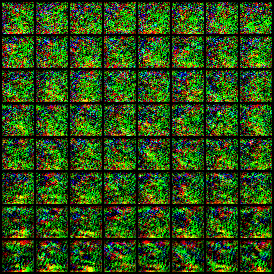

Loss: 0.0235263: 100%|██████████| 1000/1000 [13:19<00:00,  1.25it/s]


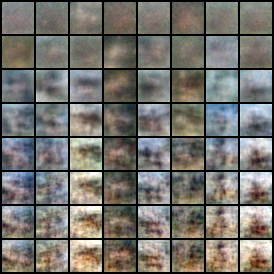

Loss: 0.0233366: 100%|██████████| 1000/1000 [13:56<00:00,  1.20it/s]


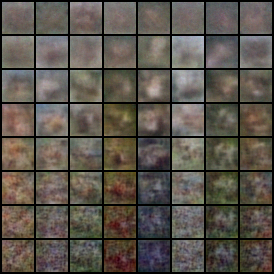

Loss: 0.0232231: 100%|██████████| 1000/1000 [13:31<00:00,  1.23it/s]


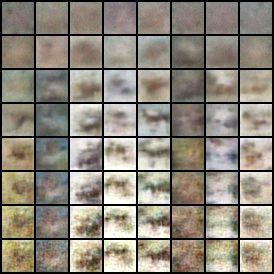

In [5]:
demo = sample(8, 8)
utils.show_image(demo)
for i in range(3):
    utils.train(model, dataloader, optimizer, loss_fn)
    demo = sample(8, 8)
    utils.show_image(demo)

## Results after 3 epochs

As you can see, the generated images are still **low quality** (blurry and noisy).

This is expected because:
- The model is relatively small
- Training is very short (only 3 epochs)
- Learning rate (1e-3) might be too high for fine details

---

## Ways to improve quality

Here are several approaches we can try:

1. **Continue training** for more epochs
2. **Make the model larger** (more channels or deeper)
3. **Change training and sampling methods** (better denoising schedules)
4. **Guide the model with timestep information** (tell it how much noise to remove)
5. **Condition on text prompts or class labels** (in our case: tell the model what class to generate, e.g., "cat" or "car")
6. **And many more...**

---

## Important note about limitations

> Due to computational resource limitations, the models in this course will remain relatively small and training will be kept short.  
> You will see this trade-off throughout all upcoming chapters.

**But here's a challenge for you:**

You can try modifying the architecture yourself and retrain with:
- Learning rate = 1e-4 (slower but more stable)
- More training steps

See if you can get better results! 🚀